# Political Text Embedding Analysis
### Examining Spread, Deviation, and Homogeneity Across Party-Reposted Content

This notebook:
1. Takes two corpora of short text documents (Democrat-reposted & Republican-reposted)
2. Embeds each using `all-MiniLM-L6-v2` (384-dimensional sentence embeddings)
3. Analyzes **magnitude** (how far embeddings are from origin) and **homogeneity** (how clustered/spread embeddings are within each party)

**Key metrics:**
- **Centroid distance**: Mean distance of each doc from the party's centroid (intra-party spread)
- **Pairwise cosine similarity**: How similar documents are to each other within each party
- **Embedding magnitude (L2 norm)**: Average vector length per party
- **Standard deviation of embeddings**: Variance per dimension
- **Inter-party distance**: How far apart the two party centroids are

## 0. Install Dependencies (Colab / fresh environment)

In [1]:
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

install('sentence-transformers')
install('scikit-learn')
install('seaborn')
install('matplotlib')
install('numpy')
install('scipy')

print('✅ All packages installed.')

✅ All packages installed.


## 1. Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.spatial.distance import cosine, pdist, squareform
from scipy.stats import ttest_ind
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
import sqlite3
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd

print('✅ Imports complete.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Imports complete.


## 2. Define Corpora

Replace the sample texts below with your own documents. Each list should contain short text strings (tweets, headlines, social posts, etc.).

In [3]:
db_path = '/content/drive/MyDrive/colabshortcuts/tiktok_breadth_first.db'

conn = sqlite3.connect(db_path)

query = """
SELECT video_description, fr.to_username
FROM videos
JOIN follow_relations AS fr
  ON videos.reposter_username = fr.from_username
WHERE fr.to_username = 'kamalahq'
  AND video_description IS NOT NULL
  AND length(trim(video_description)) > 16
ORDER BY RANDOM()
LIMIT 10000
"""

k_df = pd.read_sql_query(query, conn)

query = """
SELECT video_description, fr.to_username
FROM videos
JOIN follow_relations AS fr
  ON videos.reposter_username = fr.from_username
WHERE fr.to_username = 'teamtrump'
  AND video_description IS NOT NULL
  AND length(trim(video_description)) > 16
ORDER BY RANDOM()
LIMIT 10000
"""

t_df = pd.read_sql_query(query, conn)
conn.close()

df = pd.concat([k_df, t_df])

print(f"Total rows fetched: {len(df):,}")
print("\nLabel distribution (raw):")
print(df['to_username'].value_counts())

Total rows fetched: 20,000

Label distribution (raw):
to_username
kamalahq     10000
teamtrump    10000
Name: count, dtype: int64


In [4]:
# ── DEMOCRAT CORPUS ─────────────────────────────────────────────────────────
# Replace these with your actual documents
dem_corpus = k_df['video_description']

# ── REPUBLICAN CORPUS ────────────────────────────────────────────────────────
# Replace these with your actual documents
rep_corpus = t_df['video_description']

print(f'Democrat corpus:   {len(dem_corpus)} documents')
print(f'Republican corpus: {len(rep_corpus)} documents')

Democrat corpus:   10000 documents
Republican corpus: 10000 documents


## 3. Load Model & Embed Documents

In [5]:
MODEL_NAME = 'all-MiniLM-L6-v2'
print(f'Loading {MODEL_NAME}...')
model = SentenceTransformer(MODEL_NAME)

dem_embeddings = model.encode(dem_corpus, show_progress_bar=True, normalize_embeddings=False)
rep_embeddings = model.encode(rep_corpus, show_progress_bar=True, normalize_embeddings=False)

print(f'\nDemocrat embedding matrix shape:   {dem_embeddings.shape}')
print(f'Republican embedding matrix shape: {rep_embeddings.shape}')

Loading all-MiniLM-L6-v2...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/313 [00:00<?, ?it/s]

Batches:   0%|          | 0/313 [00:00<?, ?it/s]


Democrat embedding matrix shape:   (10000, 384)
Republican embedding matrix shape: (10000, 384)


## 4. Compute Metrics

In [6]:
def analyse_corpus(embeddings, label):
    """Compute spread, deviation, and magnitude metrics for an embedding matrix."""
    n, d = embeddings.shape

    # ── Magnitude (L2 norm of each vector) ───────────────────────────────────
    norms = np.linalg.norm(embeddings, axis=1)           # shape (n,)

    # ── Centroid & centroid distances ─────────────────────────────────────────
    centroid = embeddings.mean(axis=0)                   # shape (d,)
    centroid_dists = np.linalg.norm(embeddings - centroid, axis=1)  # Euclidean

    # ── Per-dimension standard deviation (spread in embedding space) ──────────
    per_dim_std = embeddings.std(axis=0)                 # shape (d,)

    # ── Pairwise cosine similarity ────────────────────────────────────────────
    cos_sim_matrix = cosine_similarity(embeddings)       # shape (n, n)
    # Take upper triangle (excluding diagonal)
    upper = cos_sim_matrix[np.triu_indices(n, k=1)]

    results = {
        'label':              label,
        'n':                  n,
        'centroid':           centroid,
        'norms':              norms,
        'mean_magnitude':     norms.mean(),
        'std_magnitude':      norms.std(),
        'centroid_dists':     centroid_dists,
        'mean_centroid_dist': centroid_dists.mean(),
        'std_centroid_dist':  centroid_dists.std(),
        'per_dim_std':        per_dim_std,
        'mean_per_dim_std':   per_dim_std.mean(),
        'pairwise_cos':       upper,
        'mean_pairwise_cos':  upper.mean(),
        'std_pairwise_cos':   upper.std(),
        'cos_sim_matrix':     cos_sim_matrix,
        'embeddings':         embeddings,
    }
    return results

dem_stats = analyse_corpus(dem_embeddings, 'Democrat')
rep_stats = analyse_corpus(rep_embeddings, 'Republican')

# ── Inter-party centroid distance ─────────────────────────────────────────────
inter_centroid_euclidean = np.linalg.norm(dem_stats['centroid'] - rep_stats['centroid'])
inter_centroid_cosine    = cosine(dem_stats['centroid'], rep_stats['centroid'])

print('\n' + '='*60)
print('SUMMARY OF METRICS')
print('='*60)
for s in [dem_stats, rep_stats]:
    print(f"\n── {s['label']} ({s['n']} docs) ──")
    print(f"  Magnitude (L2 norm)         mean={s['mean_magnitude']:.4f}  std={s['std_magnitude']:.4f}")
    print(f"  Centroid distance (spread)  mean={s['mean_centroid_dist']:.4f}  std={s['std_centroid_dist']:.4f}")
    print(f"  Pairwise cosine similarity  mean={s['mean_pairwise_cos']:.4f}  std={s['std_pairwise_cos']:.4f}")
    print(f"  Per-dim std (homogeneity)   mean={s['mean_per_dim_std']:.4f}")

print(f"\n── Inter-party ──")
print(f"  Centroid distance (Euclidean): {inter_centroid_euclidean:.4f}")
print(f"  Centroid distance (Cosine):    {inter_centroid_cosine:.4f}")

# ── Statistical significance of pairwise cosine similarity difference ─────────
t_stat, p_val = ttest_ind(dem_stats['pairwise_cos'], rep_stats['pairwise_cos'])
print(f"\n── t-test: pairwise cosine sim (Dem vs Rep) ──")
print(f"  t={t_stat:.4f}, p={p_val:.4f} {'*significant*' if p_val < 0.05 else '(not significant)'}")


SUMMARY OF METRICS

── Democrat (10000 docs) ──
  Magnitude (L2 norm)         mean=1.0000  std=0.0000
  Centroid distance (spread)  mean=0.8668  std=0.0697
  Pairwise cosine similarity  mean=0.2437  std=0.1114
  Per-dim std (homogeneity)   mean=0.0441

── Republican (10000 docs) ──
  Magnitude (L2 norm)         mean=1.0000  std=0.0000
  Centroid distance (spread)  mean=0.8692  std=0.0754
  Pairwise cosine similarity  mean=0.2388  std=0.1195
  Per-dim std (homogeneity)   mean=0.0442

── Inter-party ──
  Centroid distance (Euclidean): 0.0934
  Centroid distance (Cosine):    0.0180

── t-test: pairwise cosine sim (Dem vs Rep) ──
  t=215.7040, p=0.0000 *significant*


## 5. Visualisations

### 5a. PCA Scatter — 2D projection of all embeddings

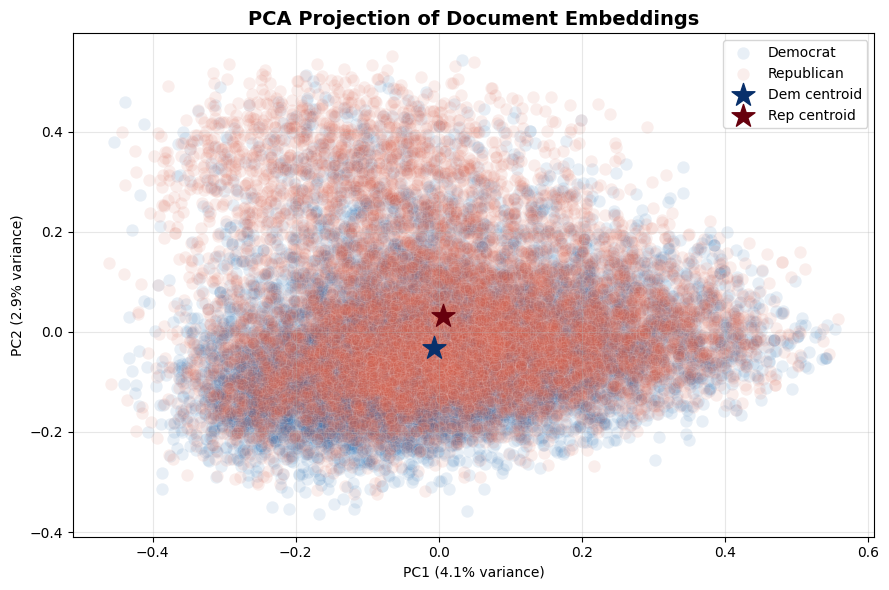

In [17]:
all_embeddings = np.vstack([dem_embeddings, rep_embeddings])
pca = PCA(n_components=2, random_state=42)
reduced = pca.fit_transform(all_embeddings)

dem_r = reduced[:len(dem_corpus)]
rep_r = reduced[len(dem_corpus):]

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(dem_r[:, 0], dem_r[:, 1], color='#2166ac', alpha=0.1, s=80, label='Democrat', edgecolors='white', linewidths=0.5)
ax.scatter(rep_r[:, 0], rep_r[:, 1], color='#d6604d', alpha=0.1, s=80, label='Republican', edgecolors='white', linewidths=0.5)

# Centroids
ax.scatter(*dem_r.mean(axis=0), color='#08306b', marker='*', s=300, zorder=5, label='Dem centroid')
ax.scatter(*rep_r.mean(axis=0), color='#67000d', marker='*', s=300, zorder=5, label='Rep centroid')

ax.set_title('PCA Projection of Document Embeddings', fontsize=14, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5b. Pairwise Cosine Similarity Heatmaps

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, stats, cmap in zip(axes, [dem_stats, rep_stats], ['Blues', 'Reds']):
    n = stats['n']
    mask = np.eye(n, dtype=bool)  # mask diagonal
    sns.heatmap(
        stats['cos_sim_matrix'],
        ax=ax,
        cmap=cmap,
        vmin=0, vmax=1,
        mask=mask,
        square=True,
        linewidths=0.3,
        cbar_kws={'label': 'Cosine Similarity'}
    )
    ax.set_title(f"{stats['label']} — Pairwise Cosine Similarity\nmean={stats['mean_pairwise_cos']:.3f}, std={stats['std_pairwise_cos']:.3f}",
                 fontweight='bold')
    ax.set_xlabel('Document index')
    ax.set_ylabel('Document index')

plt.tight_layout()
plt.show()

KeyboardInterrupt: 

### 5c. Distribution of Pairwise Cosine Similarities (Homogeneity)

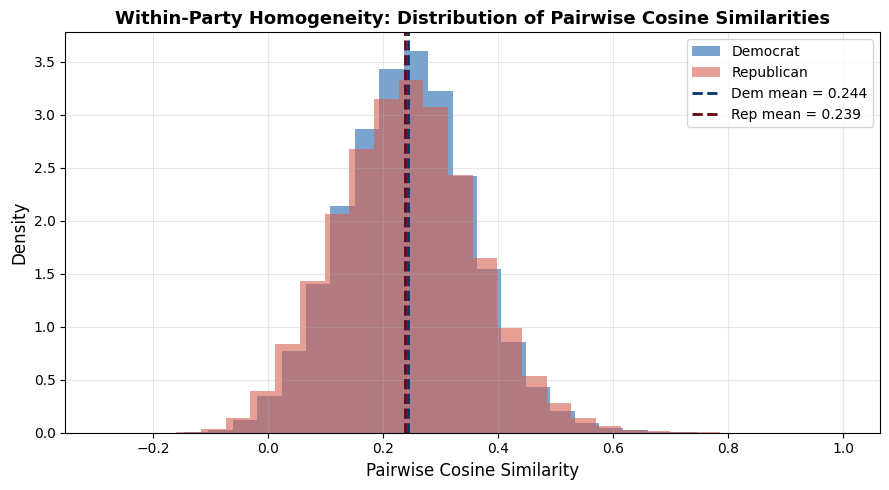

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(dem_stats['pairwise_cos'], bins=30, color='#2166ac', alpha=0.6, label='Democrat', density=True)
ax.hist(rep_stats['pairwise_cos'], bins=30, color='#d6604d', alpha=0.6, label='Republican', density=True)

ax.axvline(dem_stats['mean_pairwise_cos'], color='#08306b', linestyle='--', linewidth=2,
           label=f"Dem mean = {dem_stats['mean_pairwise_cos']:.3f}")
ax.axvline(rep_stats['mean_pairwise_cos'], color='#67000d', linestyle='--', linewidth=2,
           label=f"Rep mean = {rep_stats['mean_pairwise_cos']:.3f}")

ax.set_xlabel('Pairwise Cosine Similarity', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Within-Party Homogeneity: Distribution of Pairwise Cosine Similarities', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5d. Embedding Magnitude (L2 Norm) per Document

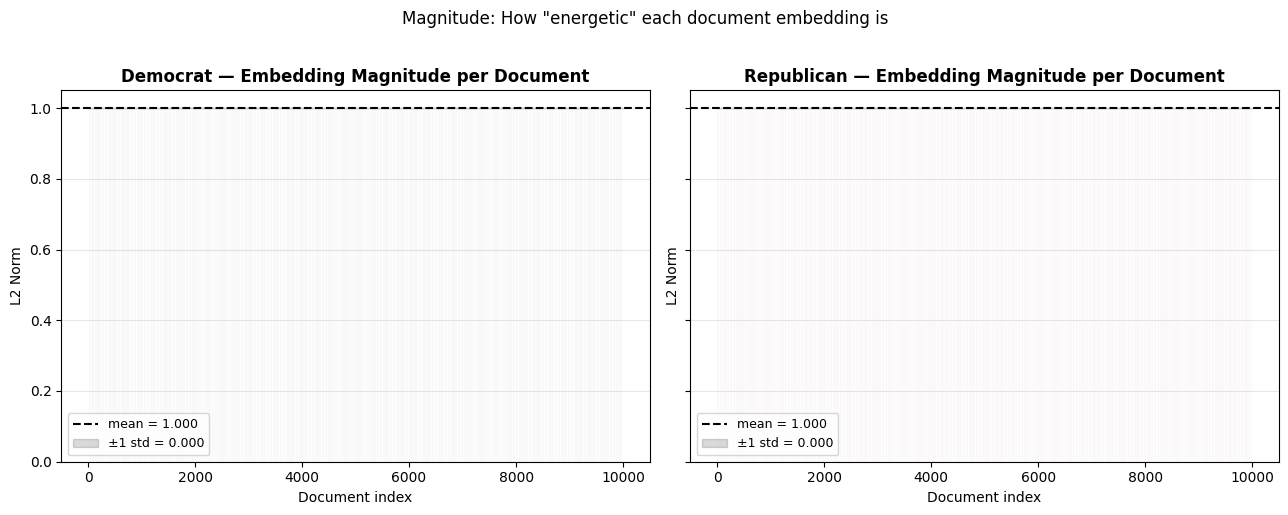

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, stats, color in zip(axes, [dem_stats, rep_stats], ['#2166ac', '#d6604d']):
    ax.bar(range(stats['n']), stats['norms'], color=color, alpha=0.8, edgecolor='white')
    ax.axhline(stats['mean_magnitude'], color='black', linestyle='--', linewidth=1.5,
               label=f"mean = {stats['mean_magnitude']:.3f}")
    ax.fill_between(
        range(stats['n']),
        stats['mean_magnitude'] - stats['std_magnitude'],
        stats['mean_magnitude'] + stats['std_magnitude'],
        alpha=0.15, color='black', label=f"±1 std = {stats['std_magnitude']:.3f}"
    )
    ax.set_title(f"{stats['label']} — Embedding Magnitude per Document", fontweight='bold')
    ax.set_xlabel('Document index')
    ax.set_ylabel('L2 Norm')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Magnitude: How "energetic" each document embedding is', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

### 5e. Centroid Distance per Document (Intra-party Spread)

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


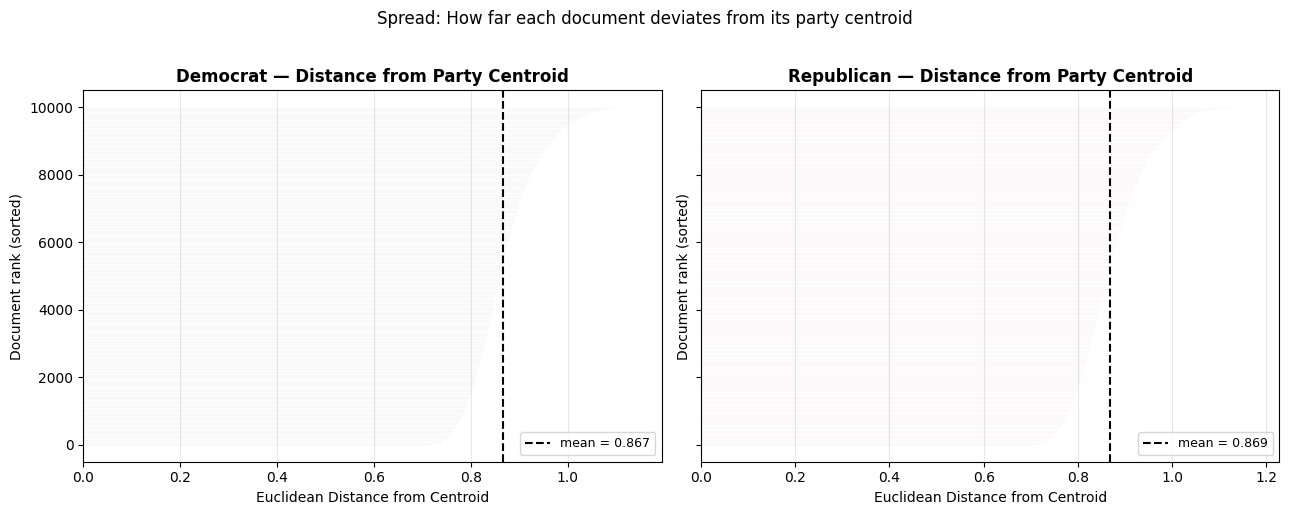

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, stats, color in zip(axes, [dem_stats, rep_stats], ['#2166ac', '#d6604d']):
    sorted_idx = np.argsort(stats['centroid_dists'])
    ax.barh(range(stats['n']), stats['centroid_dists'][sorted_idx], color=color, alpha=0.8, edgecolor='white')
    ax.axvline(stats['mean_centroid_dist'], color='black', linestyle='--', linewidth=1.5,
               label=f"mean = {stats['mean_centroid_dist']:.3f}")
    ax.set_title(f"{stats['label']} — Distance from Party Centroid", fontweight='bold')
    ax.set_xlabel('Euclidean Distance from Centroid')
    ax.set_ylabel('Document rank (sorted)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='x')

plt.suptitle('Spread: How far each document deviates from its party centroid', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

### 5f. Per-Dimension Standard Deviation (Embedding Space Variance)

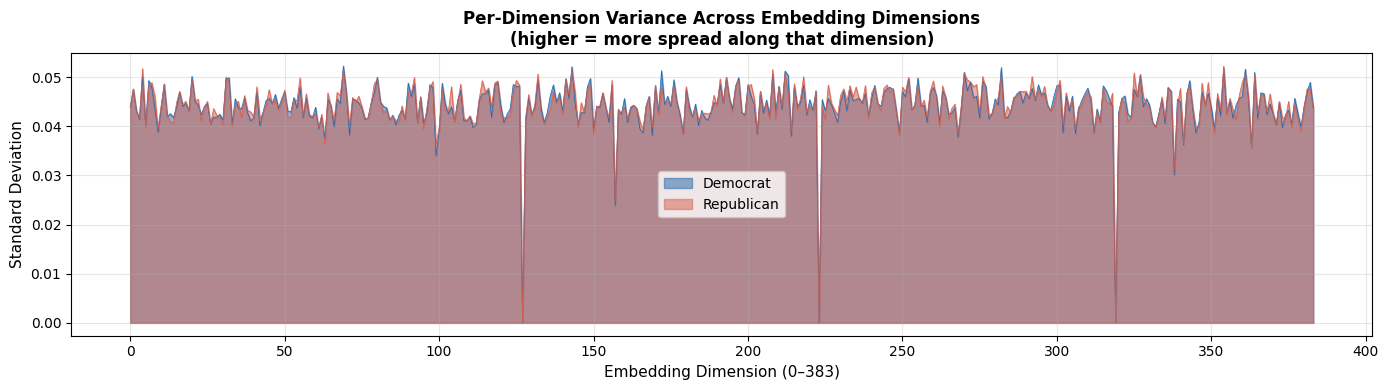

Mean per-dim std — Democrat: 0.04408 | Republican: 0.04422


In [14]:
dims = np.arange(dem_embeddings.shape[1])

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(dims, dem_stats['per_dim_std'], alpha=0.5, color='#2166ac', label='Democrat')
ax.fill_between(dims, rep_stats['per_dim_std'], alpha=0.5, color='#d6604d', label='Republican')
ax.plot(dims, dem_stats['per_dim_std'], color='#2166ac', linewidth=0.5)
ax.plot(dims, rep_stats['per_dim_std'], color='#d6604d', linewidth=0.5)

ax.set_xlabel('Embedding Dimension (0–383)', fontsize=11)
ax.set_ylabel('Standard Deviation', fontsize=11)
ax.set_title('Per-Dimension Variance Across Embedding Dimensions\n(higher = more spread along that dimension)', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Mean per-dim std — Democrat: {dem_stats['mean_per_dim_std']:.5f} | Republican: {rep_stats['mean_per_dim_std']:.5f}")

### 5g. Summary Bar Chart — Head-to-Head Metric Comparison

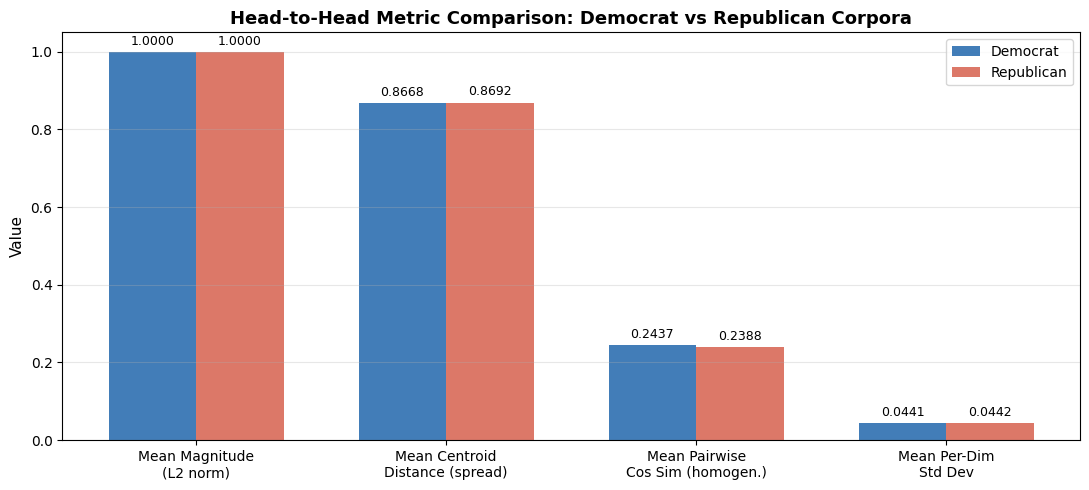

In [15]:
metrics = [
    ('Mean Magnitude\n(L2 norm)',        dem_stats['mean_magnitude'],     rep_stats['mean_magnitude']),
    ('Mean Centroid\nDistance (spread)', dem_stats['mean_centroid_dist'], rep_stats['mean_centroid_dist']),
    ('Mean Pairwise\nCos Sim (homogen.)',dem_stats['mean_pairwise_cos'],  rep_stats['mean_pairwise_cos']),
    ('Mean Per-Dim\nStd Dev',            dem_stats['mean_per_dim_std'],   rep_stats['mean_per_dim_std']),
]

labels, dem_vals, rep_vals = zip(*metrics)
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
bars1 = ax.bar(x - width/2, dem_vals, width, label='Democrat',   color='#2166ac', alpha=0.85)
bars2 = ax.bar(x + width/2, rep_vals, width, label='Republican', color='#d6604d', alpha=0.85)

ax.bar_label(bars1, fmt='%.4f', padding=3, fontsize=9)
ax.bar_label(bars2, fmt='%.4f', padding=3, fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('Value', fontsize=11)
ax.set_title('Head-to-Head Metric Comparison: Democrat vs Republican Corpora', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 6. Interpretation Guide

| Metric | What it tells you |
|---|---|
| **Mean L2 magnitude** | Average "strength" of the embedding vectors. Higher = documents use more diverse/intense vocabulary |
| **Mean centroid distance** | Intra-party spread. Higher = party shares more *diverse* content (less echo chamber) |
| **Mean pairwise cosine similarity** | Homogeneity. Higher = documents are semantically similar to each other (tighter messaging) |
| **Per-dim std deviation** | Variance across embedding dimensions. Higher = content is more topically varied |
| **Inter-party centroid distance** | Semantic distance between parties. Higher = more distinct messaging |

**Reading the results:**
- A party with **high pairwise cosine similarity + low centroid distance** is messaging with high homogeneity (consistent talking points).
- A party with **low cosine similarity + high centroid distance** is sharing more topically diverse content.
- **Inter-party centroid distance** tells you how ideologically distinct the semantic spaces are — larger distance = more polarised.

## 7. (Optional) Identify Outlier Documents

In [16]:
def show_outliers(corpus, stats, n_outliers=3):
    sorted_idx = np.argsort(stats['centroid_dists'])[::-1]
    print(f"── {stats['label']}: {n_outliers} most DISTANT from party centroid ──")
    for rank, idx in enumerate(sorted_idx[:n_outliers], 1):
        print(f"  #{rank} (dist={stats['centroid_dists'][idx]:.4f}): {corpus[idx]}")
    print()
    sorted_idx = np.argsort(stats['centroid_dists'])
    print(f"── {stats['label']}: {n_outliers} most CENTRAL (closest to centroid) ──")
    for rank, idx in enumerate(sorted_idx[:n_outliers], 1):
        print(f"  #{rank} (dist={stats['centroid_dists'][idx]:.4f}): {corpus[idx]}")
    print()

show_outliers(dem_corpus, dem_stats)
show_outliers(rep_corpus, rep_stats)

── Democrat: 3 most DISTANT from party centroid ──
  #1 (dist=1.1374): What is the integral of [(2x2 -1)/(4x-1)(x2 +1)] dx. You can’t use notes or a calculator. And your in 3rd Grade
  #2 (dist=1.1363): Animals are a lifetime commitment. Please keep that in mind when “holiday shopping” animals are not gifts to be given. They are not there for you to buy just for them to end up in a shelter two years later. Do your research and ensure you are ready for the responsibility of owning a pet before adopting. 
  #3 (dist=1.1335): I took the LSAT while 5 months pregnant. Gave birth 6 weeks before starting law school.  Suffered PPD my first year.  Worked full time, breastfed and went to law school at night for a year. Got a 4.0 that semester. Struggled balancing motherhood and school for 3 years. Studied every single day for 3 months for the bar exam.  My grandmother passed the week of the bar exam.   And I passed with a score high enough to practice in any UBE jurisdiction.  #barexam #lawschoo